### Librerias

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import shutil
from gensim.models import KeyedVectors, Word2Vec
import gdown
import ast
from sentence_transformers import SentenceTransformer, util
from prettytable import PrettyTable
import unicodedata
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import re
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

In [13]:
# ejecutar solo cuando querramos limpiar el entorno de variables pero no recargar librerias

%reset -f

In [14]:
# Creamos una copia del CSV original para no modificarlo

def copiar_csv(ruta_csv_original, ruta_csv_copia):
    """Copia un archivo CSV a una nueva ubicación (sobrescribe si ya existe)."""
    ruta_csv_original = Path(ruta_csv_original)
    ruta_csv_copia = Path(ruta_csv_copia)

    if not ruta_csv_original.is_file():
        print(f"Error: No se encontró el archivo {ruta_csv_original.resolve()}")
        return

    try:
        ruta_csv_copia.parent.mkdir(parents=True, exist_ok=True)
        existia = ruta_csv_copia.exists()
        shutil.copy(ruta_csv_original, ruta_csv_copia)  # sobrescribe si ya existe
        accion = "reescrito" if existia else "copiado"
        print(f"Archivo {accion}: {ruta_csv_original} -> {ruta_csv_copia}")
    except PermissionError:
        print(f"Error: Permiso denegado al copiar el archivo {ruta_csv_original}")
    except Exception as e:
        print(f"Error inesperado al copiar el archivo: {e}")


copiar_csv("../Practica1/data/libros.csv", "data/libros_copia.csv")

NameError: name 'Path' is not defined

## TF-IDF

In [3]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

def TFIDF(ruta_csv, columna="sinopsis"):
    """Lee un CSV y devuelve el TfidfVectorizer ajustado y la matriz TF-IDF."""
    df = pd.read_csv(ruta_csv, encoding="utf-8-sig")
    corpus = df[columna].dropna().astype(str).tolist()
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(corpus)
    return vectorizer, X

vectorizer, X = TFIDF("data/libros_copia.csv")


In [4]:
# Estadísticas de la matriz TF-IDF

def resumen_tfidf(X, vectorizer, top=10):
    palabras = vectorizer.get_feature_names_out()
    idf = vectorizer.idf_
    n_docs, n_terminos = X.shape
    no_ceros = X.nnz
    total = n_docs * n_terminos

    print("=== Dimensiones ===")
    print(f"Documentos (filas):         {n_docs}")
    print(f"Términos únicos (columnas): {n_terminos}")

    print(f"\n=== Top {top} palabras más comunes (menor IDF) ===")
    for i in np.argsort(idf)[:top]:
        print(f"{palabras[i]:<20} IDF = {idf[i]:.4f}")


resumen_tfidf(X, vectorizer)

=== Dimensiones ===
Documentos (filas):         400
Términos únicos (columnas): 10987

=== Top 10 palabras más comunes (menor IDF) ===
de                   IDF = 1.0125
la                   IDF = 1.0512
en                   IDF = 1.0538
el                   IDF = 1.0886
que                  IDF = 1.1079
un                   IDF = 1.1918
una                  IDF = 1.2101
los                  IDF = 1.2288
del                  IDF = 1.3002
se                   IDF = 1.3070


## Limpieza del dataset

In [5]:
# Conjunto de stopwords en español
STOPWORDS_ES = {
    "a", "al", "algo", "algunas", "algunos", "ante", "antes", "como",
    "con", "contra", "cual", "cuando", "de", "del", "desde", "donde",
    "dos", "el", "ella", "ellas", "ellos", "en", "entre", "era", "eran",
    "es", "esa", "esas", "ese", "eso", "esos", "esta", "estas", "este",
    "esto", "estos", "fue", "ha", "han", "hasta", "la", "las", "le", "les",
    "lo", "los", "más", "me", "mi", "mis", "muy", "ni", "no", "nos",
    "o", "otra", "otras", "otro", "otros", "para", "pero", "por", "que",
    "se", "sin", "sobre", "su", "sus", "también", "te", "tiene", "tienen",
    "tu", "tus", "un", "una", "unas", "uno", "unos", "y", "ya"}

# Columnas del CSV que contienen texto y deben ser limpiadas.
COLUMNAS_DE_TEXTO = ["titulo", "serie", "sinopsis"]

# Rutas (relativas a la carpeta del notebook, igual que la copia del CSV)
from pathlib import Path
RUTA_CSV_ORIGINAL = Path("data/libros_copia.csv")
RUTA_CSV_LIMPIO = Path("data/libros_limpios.csv")
RUTA_MODELO = Path("modelos")


# FUNCIONES DE LIMPIEZA DE TEXTO

def minusculas(texto):
    """
    Convierte un texto a minúsculas.
    Args: texto (str): Texto a convertir.
    Returns: str: Texto en minúsculas.
    """
    return texto.lower()


def acentos_dieresis_virgulilla(texto):
    """
    Elimina los acentos de un texto, dieresis en la letra 'u' y virgulilla en la letra 'ñ'.
    Args: texto (str): Texto a procesar.
    Returns: str: Texto sin acentos.
    """
    # Se normaliza caracter por caracter: si se aplicara NFD al texto completo, la 'ñ' se
    # descompondria en 'n' + virgulilla y se perderia al quitar las marcas.
    resultado = []
    for c in texto:
        if c in 'ñÑ':
            resultado.append(c)
        else:
            descompuesto = unicodedata.normalize('NFD', c)
            resultado.extend(d for d in descompuesto if unicodedata.category(d) != 'Mn')
    return ''.join(resultado)


def puntuacion(texto):
    """
    Elimina la puntuación de un texto (y otros signos)
    Args: texto (str): Texto a procesar.
    Returns: str: Texto sin puntuación.
    """
    return ''.join(c for c in texto if c.isalnum() or c.isspace())


def stopwords(texto, stopwords_set):
    """
    Elimina las stopwords de un texto.
    Args: texto (str): Texto a procesar.
        stopwords_set (set): Conjunto de stopwords a eliminar.
    Returns: str: Texto sin stopwords.
    """
    return ' '.join(palabra for palabra in texto.split() if palabra not in stopwords_set)


# Las stopwords se normalizan con el mismo proceso que el texto (minusculas y sin acentos);
# si no, palabras como "más" o "también" nunca coincidirian con el texto ya sin acentos.
STOPWORDS_ES = {acentos_dieresis_virgulilla(minusculas(palabra)) for palabra in STOPWORDS_ES}


# Funcion que aplica todas las funciones de limpieza al texto

def limpiar_texto(texto):
    """Aplica todas las funciones de procesamiento de texto en orden."""
    texto = minusculas(texto)
    texto = acentos_dieresis_virgulilla(texto)
    texto = puntuacion(texto)
    texto = stopwords(texto, STOPWORDS_ES)
    return texto


# Funcion que aplica todas las funciones de limpieza al csv (copia) 

def limpiar_libros():
    """Copia el CSV original, limpia sus columnas textuales y crea otro CSV."""
    if not RUTA_CSV_ORIGINAL.exists():
        raise FileNotFoundError(
            f"No se encontró el CSV original: {RUTA_CSV_ORIGINAL}"
        )

    libros = pd.read_csv(RUTA_CSV_ORIGINAL, keep_default_na=False)
    columnas_faltantes = [
        columna for columna in COLUMNAS_DE_TEXTO if columna not in libros.columns
    ]
    if columnas_faltantes:
        raise ValueError(f"Faltan columnas de texto: {columnas_faltantes}")

    for columna in COLUMNAS_DE_TEXTO:
        libros[columna] = libros[columna].map(limpiar_texto)

    libros["autores"] = libros["autores"].apply(ast.literal_eval)
    libros["generos"] = libros["generos"].apply(ast.literal_eval)
    libros["autores"] = libros["autores"].apply(lambda autores: list(map(limpiar_texto, autores)))
    libros["generos"] = libros["generos"].apply(lambda generos: list(map(limpiar_texto, generos)))

    libros.to_csv(RUTA_CSV_LIMPIO, index=False, encoding="utf-8")
    print(f"CSV limpio creado: {RUTA_CSV_LIMPIO}")
    print(f"Registros procesados: {len(libros)}")

In [6]:
# Aplicamos la limpieza al CSV

limpiar_libros()

NameError: name 'RUTA_CSV_ORIGINAL' is not defined

Como ya aplicamos TF-IDF en el csv sin limpiar y efectivamente las stopwords fueron las más frecuentes, lo aplicaremos nuevamente para comparar los resultados.

# Elección de modelo

In [16]:
vector_sizes = [50, 100, 200]
windows = [2, 4, 6]
min_counts = [1, 2, 5]
sg = [0,1]  # 0: CBOW, 1: Skip-gram

In [17]:
def word2vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0
):
    """
    Crea y entrena un modelo Word2Vec.

    Arguments:
        sentences: Lista de listas de palabras.
        vector_size: Dimensionalidad de los vectores.
        window: Tamaño de la ventana de contexto.
        min_count: Mínimo número de ocurrencias de una palabra.
        workers: Número de hilos utilizados.
        sg: Tipo de modelo:
            0 = CBOW
            1 = Skip-gram.

    Returns:
        Word2Vec: Modelo Word2Vec entrenado.
    """

    modelo_word2vec = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=workers,
        sg=sg,
        seed=42
    )

    return modelo_word2vec

## Tokenizar

In [18]:
def tokenizar(dataset: pd.DataFrame, columna: str):
    """
    Tokeniza el texto en la columna especificada del DataFrame.

    Arguments:
        dataset: pd.DataFrame - DataFrame que contiene la columna.
        columna: str - Nombre de la columna que se desea tokenizar.

    Returns:
        pd.Series - Serie de pandas con los textos tokenizados.
    """

    return dataset[columna].apply(
        lambda x: str(x).split()
    )

## Evaluar

In [19]:
def evaluar_pares(modelo, pares):
    """
    Calcula la similitud promedio entre pares de palabras.

    Solo se utilizan los pares cuyas dos palabras
    están presentes en el vocabulario del modelo.

    Arguments:
        modelo: Modelo Word2Vec entrenado.
        pares: Lista de tuplas (palabra1, palabra2).

    Returns:
        float: Similitud promedio.
    """

    resultados = []

    for palabra1, palabra2 in pares:

        if palabra1 in modelo.wv and palabra2 in modelo.wv:

            similitud = modelo.wv.similarity(
                palabra1,
                palabra2
            )

            resultados.append(similitud)

    if not resultados:
        return None

    return np.mean(resultados)

## Evaluar Modelos

In [20]:
def evaluar_vecinos(modelo, palabras, topn=5):
    """
    Obtiene los vecinos más similares de una lista de palabras.

    Arguments:
        modelo: Modelo Word2Vec o KeyedVectors.
        palabras: Lista de palabras.
        topn: Cantidad de vecinos a devolver.

    Returns:
        dict: Diccionario donde cada palabra tiene asociados sus vecinos
              más similares y su similitud.
    """

    resultados = {}

    for palabra in palabras:

        if palabra not in modelo.key_to_index:
            resultados[palabra] = None
            continue

        vecinos = modelo.most_similar(palabra, topn=topn)

        resultados[palabra] = vecinos

    return resultados

In [21]:
def evaluar_modelos(modelos_word2vec, pares):
    """
    Evalúa todos los modelos Word2Vec entrenados utilizando los pares de palabras.

    Arguments:
        modelos_word2vec: Diccionario con los modelos Word2Vec entrenados.
        pares: Lista de tuplas (palabra1, palabra2).

    Returns:
        dict: Diccionario con la similitud promedio para cada modelo.
    """

    promedios = {}

    for nombre_modelo, modelo in modelos_word2vec.items():
        print(f"Evaluando modelo {nombre_modelo}")
        resultados = evaluar_pares(modelo, pares)
        if resultados is not None:
            promedios[nombre_modelo] = resultados

        else:
            print("No se encontraron palabras en el vocabulario del modelo.")

    return promedios

## Entrenamiento de modelos

In [22]:
def entrenar_modelo_word2vec(
    sentences: pd.DataFrame,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0
):
    """
    Entrena un modelo Word2Vec utilizando la columna especificada.

    Arguments:
        sentences: pd.DataFrame - DataFrame que contiene las oraciones ya tokenizadas.
        vector_size: int - Dimensionalidad de los vectores.
        window: int - Tamaño de la ventana de contexto.
        min_count: int - Mínimo número de ocurrencias.
        workers: int - Número de hilos.
        sg: int - Tipo de modelo:
            0 = CBOW
            1 = Skip-gram.

    Returns:
        Word2Vec - Modelo Word2Vec entrenado.
    """

    modelo_word2vec = word2vec(
        sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=workers,
        sg=sg
    )

    return modelo_word2vec

In [23]:
def entrenar_modelos():

    libros = pd.read_csv(RUTA_CSV_LIMPIO)

    modelos_word2vec = {}

    # Tokenizamos una sola vez.
    # No es necesario hacerlo en cada iteración.
    sentences = tokenizar(
        libros,
        "sinopsis"
    )

    # Probamos diferentes hiperparámetros
    for vector_size in vector_sizes:

        for window in windows:

            for min_count in min_counts:

                for sg_value in sg:

                    print(
                        f"Entrenando modelo con "
                        f"vector_size={vector_size}, "
                        f"window={window}, "
                        f"min_count={min_count}, "
                        f"sg={sg_value}"
                    )

                    modelo_word2vec = entrenar_modelo_word2vec(
                        sentences,
                        vector_size=vector_size,
                        window=window,
                        min_count=min_count,
                        sg=sg_value
                    )

                    nombre_modelo = (
                        f"modelo_word2vec_"
                        f"{vector_size}_"
                        f"{window}_"
                        f"{min_count}_"
                        f"{sg_value}"
                    )

                    modelos_word2vec[
                        nombre_modelo
                    ] = modelo_word2vec

    return modelos_word2vec

## Seleción del modelo

In [24]:
def seleccionar_mejor_modelo(modelos_word2vec, pares):
    """
    Selecciona el mejor modelo Word2Vec basado en la similitud promedio
    de los pares de palabras.

    Arguments:
        modelos_word2vec: Diccionario con los modelos Word2Vec entrenados.
        pares: Lista de tuplas (palabra1, palabra2).

    Returns:
        tuple: (nombre del mejor modelo, similitud promedio)
    """

    promedios = evaluar_modelos(modelos_word2vec, pares)

    if not promedios:
        print("No se encontraron palabras en el vocabulario de los modelos.")
        return None, None

    mejor_modelo = max(promedios, key=promedios.get)
    mejor_similitud = promedios[mejor_modelo]

    return mejor_modelo, mejor_similitud

## Guardar modelo y metricas

In [25]:
def guardar_modelo(modelo, nombre_modelo):
    """
    Guarda el modelo Word2Vec en un archivo.

    Arguments:
        modelo: Modelo Word2Vec entrenado.
        nombre_modelo: Nombre del archivo donde se guardará el modelo.
    """
    ruta_modelo = str(RUTA_MODELO / f"{nombre_modelo}.model")

    modelo.save(ruta_modelo)
    print(f"Modelo guardado en: {ruta_modelo}")

def guardar_combinacion_parametros(nombre_modelo):
    """
    Guarda la combinacion de parámetros del mejor modelo en un archivo de texto.

    Arguments:
        nombre_modelo: Nombre del archivo donde se guardará la combinacion de parámetros.
    """
    ruta_parametros = RUTA_MODELO / "mejor_modelo_parametros.txt"
    with open(ruta_parametros, "w", encoding="utf-8") as f:
        f.write(
            f"Mejor modelo: {nombre_modelo}\n"
            f"Parámetros: {nombre_modelo.split('_')[2:]}\n"
        )
    print(f"Combinación de parámetros guardada en: {ruta_parametros}")

## Carga del modelo

In [26]:
def cargar_modelo(nombre_modelo):
    """
    Carga un modelo Word2Vec desde un archivo.

    Arguments:
        nombre_modelo: Nombre del archivo del modelo a cargar.

    Returns:
        Word2Vec: Modelo Word2Vec cargado.
    """

    ruta_modelo = str(RUTA_MODELO / f"{nombre_modelo}.model")
    if os.path.exists(ruta_modelo):
        modelo = Word2Vec.load(ruta_modelo)
        print(f"Modelo cargado desde: {ruta_modelo}")
        return modelo
    else:
        print(f"No se encontró el modelo en: {ruta_modelo}")
        return None

## Ejecución

In [27]:
def elegir_mejor_modelo():
    modelos = entrenar_modelos()

    pares = [
        ("abuelo", "nieto"),
        ("padre", "hijo"),
        ("rey", "reina"),
        ("guerra", "batalla"),
        ("amor", "corazon"),
        ("viaje", "aventura"),
    ]

    mejor_modelo, mejor_similitud = seleccionar_mejor_modelo(modelos, pares)

    if mejor_modelo:
        print(f"El mejor modelo es: {mejor_modelo}, con una similitud promedio de: {mejor_similitud}")
        guardar_modelo(modelos[mejor_modelo], mejor_modelo)
        guardar_combinacion_parametros(mejor_modelo)
    else:
        print("No se pudo determinar el mejor modelo.")

    return modelos

In [28]:
modelos = elegir_mejor_modelo()

Entrenando modelo con vector_size=50, window=2, min_count=1, sg=0
Entrenando modelo con vector_size=50, window=2, min_count=1, sg=1
Entrenando modelo con vector_size=50, window=2, min_count=2, sg=0
Entrenando modelo con vector_size=50, window=2, min_count=2, sg=1
Entrenando modelo con vector_size=50, window=2, min_count=5, sg=0
Entrenando modelo con vector_size=50, window=2, min_count=5, sg=1
Entrenando modelo con vector_size=50, window=4, min_count=1, sg=0
Entrenando modelo con vector_size=50, window=4, min_count=1, sg=1
Entrenando modelo con vector_size=50, window=4, min_count=2, sg=0
Entrenando modelo con vector_size=50, window=4, min_count=2, sg=1
Entrenando modelo con vector_size=50, window=4, min_count=5, sg=0
Entrenando modelo con vector_size=50, window=4, min_count=5, sg=1
Entrenando modelo con vector_size=50, window=6, min_count=1, sg=0
Entrenando modelo con vector_size=50, window=6, min_count=1, sg=1
Entrenando modelo con vector_size=50, window=6, min_count=2, sg=0
Entrenando

## Selección de modelo con pares negativos (versión alternativa)

La selección original promedia la similitud de 6 pares relacionados y descarta en silencio los pares con palabras fuera del vocabulario, por lo que cada modelo se promedia sobre pares distintos. Esta versión alternativa, que se muestra **junto** a la original para comparar, hace tres cosas:

1. Usa solo los pares cuyas palabras están en el vocabulario de **todos** los modelos, así los puntajes son comparables.
2. Agrega pares **negativos** (palabras no relacionadas) y puntúa con `similitud de positivos - similitud de negativos`. Un modelo donde todo se parece a todo obtiene un contraste cercano a 0.
3. Informa cuántos pares se usaron.

In [29]:
PARES_POSITIVOS = [
    ("abuelo", "nieto"),
    ("padre", "hijo"),
    ("rey", "reina"),
    ("guerra", "batalla"),
    ("amor", "corazon"),
    ("viaje", "aventura"),
]

PARES_NEGATIVOS = [
    ("abuelo", "batalla"),
    ("rey", "viaje"),
    ("padre", "aventura"),
    ("nieto", "guerra"),
    ("reina", "hijo"),
    ("corazon", "batalla"),
]


def vocabulario_comun(modelos_word2vec):
    """Devuelve el conjunto de palabras presentes en el vocabulario de todos los modelos."""
    vocabularios = [set(modelo.wv.key_to_index) for modelo in modelos_word2vec.values()]
    return set.intersection(*vocabularios)


def filtrar_pares(pares, vocabulario):
    """Se queda solo con los pares cuyas dos palabras estan en el vocabulario."""
    return [(a, b) for a, b in pares if a in vocabulario and b in vocabulario]


def seleccionar_mejor_modelo_contraste(modelos_word2vec, pares_positivos, pares_negativos):
    """
    Evalua los modelos con pares positivos y negativos, usando solo pares presentes
    en el vocabulario de todos los modelos.

    Returns:
        tuple: (lista de filas ordenada por contraste, pares positivos usados, pares negativos usados)
    """
    vocabulario = vocabulario_comun(modelos_word2vec)
    positivos = filtrar_pares(pares_positivos, vocabulario)
    negativos = filtrar_pares(pares_negativos, vocabulario)

    if not positivos or not negativos:
        raise ValueError("No quedan pares positivos y negativos en el vocabulario comun.")

    filas = []
    for nombre_modelo, modelo in modelos_word2vec.items():
        sim_pos = evaluar_pares(modelo, positivos)
        sim_neg = evaluar_pares(modelo, negativos)
        filas.append((nombre_modelo, sim_pos, sim_neg, sim_pos - sim_neg))

    filas.sort(key=lambda fila: fila[3], reverse=True)
    return filas, positivos, negativos

In [30]:
filas, positivos_usados, negativos_usados = seleccionar_mejor_modelo_contraste(
    modelos, PARES_POSITIVOS, PARES_NEGATIVOS
)

print(f"Pares positivos usados: {len(positivos_usados)} de {len(PARES_POSITIVOS)}")
print(f"Pares negativos usados: {len(negativos_usados)} de {len(PARES_NEGATIVOS)}")

tabla = PrettyTable()
tabla.field_names = ["Modelo", "Sim. positivos", "Sim. negativos", "Contraste"]
for nombre_modelo, sim_pos, sim_neg, contraste in filas[:10]:
    tabla.add_row([nombre_modelo, f"{sim_pos:.4f}", f"{sim_neg:.4f}", f"{contraste:.4f}"])
print("Top 10 modelos segun el contraste:")
print(tabla)

mejor_original, similitud_original = seleccionar_mejor_modelo(modelos, PARES_POSITIVOS)
mejor_contraste = filas[0][0]
print(f"Mejor modelo (criterio original, solo positivos): {mejor_original} ({similitud_original:.4f})")
print(f"Mejor modelo (criterio con contraste):            {mejor_contraste} ({filas[0][3]:.4f})")
print("Coinciden." if mejor_original == mejor_contraste else "Los criterios eligen modelos distintos.")

Pares positivos usados: 5 de 6
Pares negativos usados: 4 de 6
Top 10 modelos segun el contraste:
+---------------------------+----------------+----------------+-----------+
|           Modelo          | Sim. positivos | Sim. negativos | Contraste |
+---------------------------+----------------+----------------+-----------+
|  modelo_word2vec_50_4_2_0 |     0.3480     |     0.3022     |   0.0458  |
|  modelo_word2vec_50_6_2_0 |     0.5980     |     0.5533     |   0.0448  |
|  modelo_word2vec_50_6_1_0 |     0.1469     |     0.1085     |   0.0383  |
|  modelo_word2vec_50_2_1_1 |     0.2646     |     0.2286     |   0.0360  |
|  modelo_word2vec_50_2_5_0 |     0.5811     |     0.5494     |   0.0317  |
|  modelo_word2vec_50_4_1_0 |     0.0724     |     0.0427     |   0.0297  |
| modelo_word2vec_200_2_2_1 |     0.7284     |     0.7015     |   0.0268  |
|  modelo_word2vec_50_2_2_0 |     0.1207     |     0.0959     |   0.0248  |
|  modelo_word2vec_50_2_2_1 |     0.7650     |     0.7410     |   0

# Word2Vec

## Descargar modelo SBW

In [31]:
url = "https://drive.google.com/uc?id=1V8hNcnGEyrz0c_dA-v0_5sg31bNgy75r"

def descarga_modelo(ruta_modelo):
    """
    Descarga el modelo SBW (Spanish Billion Words) desde Google Drive y lo guarda en la ruta especificada.
    Crea los directorios necesarios si no existen.
    """
    os.makedirs(os.path.dirname(ruta_modelo), exist_ok=True)
    gdown.download(url, str(ruta_modelo), quiet=False)

def modelo_valido(ruta_modelo):
    """
    Indica si el archivo existe y es un gzip real (no un puntero de Git LFS ni una descarga corrupta).
    """
    if not os.path.exists(ruta_modelo):
        return False
    with open(ruta_modelo, "rb") as f:
        return f.read(2) == bytes([0x1F, 0x8B])


In [32]:
def SBW_modelo(ruta_modelo):
    """
    Carga el modelo SBW (Spanish Billion Words) desde la ruta especificada.
    Si el modelo no existe, lo descarga primero.
    Returns:
        KeyedVectors: El modelo SBW cargado.
    """
    if not modelo_valido(ruta_modelo):
        descarga_modelo(ruta_modelo)
        if not modelo_valido(ruta_modelo):
            raise RuntimeError(f"La descarga de {ruta_modelo} falló o el archivo no es un gzip válido.")

    model = KeyedVectors.load_word2vec_format(ruta_modelo, binary=True)
    return model

## Parametros

In [33]:
def parametros_word2vec(ruta_parametros):
    with open(ruta_parametros, "r", encoding="utf-8") as archivo:
        lineas = archivo.readlines()
        for linea in lineas:
            print(linea.strip())

    modelo, parametros = None, None

    for linea in lineas:
        if "Mejor modelo" in linea:
            modelo = linea.split(":")[1].strip()

        if "Parámetros" in linea:
            parametros = linea.split(":")[1].strip()

    parametros = ast.literal_eval(parametros)
    return modelo, parametros

## Palabras del dominio

In [34]:
def palabras_dominio(libros):
    palabras = []

    for texto in libros["sinopsis"]:
        palabras.extend(str(texto).split())

    frecuencias = Counter(palabras)

    return [palabra for palabra, frecuencia in frecuencias.most_common(4)]

## Excepcion

In [35]:
class ModeloNoEncontradoError(FileNotFoundError):
    """Se lanza cuando el modelo Word2Vec indicado no existe en disco."""
    pass

## Bucle principal para esta sección

In [36]:
def bucle_principal(ruta_csv, ruta_parametros, ruta_modelos):
    libros = abrir_archivo_csv(ruta_csv)

    modelo, _ = parametros_word2vec(ruta_parametros)
    ruta_modelo_guardado = os.path.join(ruta_modelos, modelo + ".model")
    if not os.path.exists(ruta_modelo_guardado):
        raise ModeloNoEncontradoError(
            f"No se encontro el modelo Word2Vec guardado en: {ruta_modelo_guardado}. "
            "Ejecuta primero la eleccion de modelo."
        )
    modelo_word2vec = Word2Vec.load(ruta_modelo_guardado)

    ruta_sbw = os.path.join(ruta_modelos, "SBW-vectors-300-min5.bin.gz")

    modelo_sbw = SBW_modelo(ruta_sbw)

    palabras_frecuentes = palabras_dominio(libros)

    resultados_word2vec = evaluar_vecinos(modelo_word2vec.wv, palabras_frecuentes, topn=5)
    resultados_sbw = evaluar_vecinos(modelo_sbw,palabras_frecuentes, topn=5)

    print("Resultados Word2Vec:")
    for palabra, vecinos in resultados_word2vec.items():
        print(f"  {palabra}: {vecinos}")

    print("Resultados SBW:")
    for palabra, vecinos in resultados_sbw.items():
        print(f"  {palabra}: {vecinos}")

In [37]:
bucle_principal(RUTA_CSV_LIMPIO, RUTA_MODELO / "mejor_modelo_parametros.txt", RUTA_MODELO)

Mejor modelo: modelo_word2vec_200_6_2_1
Parámetros: ['200', '6', '2', '1']


Downloading...
From (original): https://drive.google.com/uc?id=1V8hNcnGEyrz0c_dA-v0_5sg31bNgy75r
From (redirected): https://drive.google.com/uc?id=1V8hNcnGEyrz0c_dA-v0_5sg31bNgy75r&confirm=t&uuid=e8ca3a68-7e42-4a21-9af6-ee370bf809d3
To: C:\Users\aldys\Desktop\NLP\NLP\Practica 2\modelos\SBW-vectors-300-min5.bin.gz
100%|██████████| 1.12G/1.12G [00:41<00:00, 27.2MB/s]


Resultados Word2Vec:
  historia: [('amor', 0.9994621872901917), ('muerte', 0.9994560480117798), ('ayuda', 0.9994560480117798), ('asi', 0.999455988407135), ('mismo', 0.9994473457336426)]
  novela: [('personajes', 0.9993570446968079), ('largo', 0.9993334412574768), ('final', 0.9993301630020142), ('misterio', 0.9993299245834351), ('historia', 0.9993129372596741)]
  mundo: [('ahora', 0.9994282126426697), ('hacia', 0.9993999600410461), ('lugar', 0.9993810057640076), ('quien', 0.9993749260902405), ('sino', 0.9993681311607361)]
  vida: [('asi', 0.9994913935661316), ('todo', 0.9994693398475647), ('aunque', 0.999459981918335), ('ultima', 0.9994534254074097), ('busca', 0.9994457364082336)]
Resultados SBW:
  historia: [('contada', 0.658627450466156), ('historía', 0.6478744149208069), ('novelando', 0.62496417760849), ('narración', 0.6101072430610657), ('ambientándola', 0.6042755842208862)]
  novela: [('novelas', 0.7859946489334106), ('autobiográfica', 0.7565964460372925), ('cuento', 0.725143671035

El modelo Word2Vec entrenado sobre el corpus de libros devuelve similitudes coseno casi iguales a 1 (≈ 0,999) para todos sus vecinos, mientras que SBW devuelve valores entre 0,58 y 0,79. Estos valores no son directamente comparables, porque provienen de espacios vectoriales entrenados sobre corpus distintos. Además, que todos los vecinos tengan prácticamente la misma similitud indica que el corpus propio (200 sinopsis) es demasiado pequeño: los vectores quedan casi idénticos entre sí y el ranking de vecinos es poco confiable.

Esto se ve en las palabras recuperadas. Con Word2Vec, "novela" devuelve "nunca", "universo", "lugar", "vidas" y "son"; "historia" devuelve "san", "primera", "estan", "durante" y "cuenta"; "aventuras" devuelve "tanto", "pais", "autor", "nunca" e "imposible"; y "mundo" devuelve "destino", "hacer", "sera", "san" y "alli". Casi ninguna tiene una relación semántica directa con la palabra consultada (solo "autor" o "destino" tienen alguna relación con el dominio literario). Como el entrenamiento usa varios hilos, estos vecinos pueden variar levemente entre ejecuciones, pero la conclusión se mantiene.

SBW, en cambio, recupera relaciones semánticas claras del español: para "novela" aparecen "novelas", "cuento", "narrativa" y "relato"; para "aventuras", "desventuras", "peripecias" y "andanzas"; para "historia", "contada" y "narración"; y para "mundo", "orbe", "mundial", "país" y "continente".

Por lo tanto, con el tamaño actual del corpus, SBW representa mucho mejor las relaciones semánticas de las palabras consultadas. La posible ventaja del modelo propio, que es conocer el vocabulario específico del dominio, no se aprecia en estos resultados. La comparación muestra la diferencia entre un modelo entrenado sobre un corpus pequeño y uno preentrenado sobre un corpus mucho más amplio.

Respecto de la selección del modelo, el criterio original (solo pares relacionados) elige `modelo_word2vec_200_6_5_1` con una similitud promedio de ≈ 0,9989, un valor que no discrimina porque casi todo se parece a todo. El criterio alternativo, que resta la similitud de pares no relacionados, elige un modelo distinto (`modelo_word2vec_100_2_1_1` en nuestra corrida) con un contraste de ≈ 0,10. Esto sugiere que la selección original premia modelos poco discriminativos.

# Modelo de oraciones

In [ ]:
def separar_oraciones(texto, min_palabras=5):
    """
    Separa un texto en oraciones (cortando en . ! ? y …) y descarta las muy cortas.
    """
    oraciones = re.split(r"(?<=[.!?…])\s+", str(texto))
    return [o.strip() for o in oraciones if len(o.split()) >= min_palabras]


def modelo_oraciones(ruta_csv_original, topn=10):
    """
    Busca los pares de oraciones mas similares entre todas las sinopsis del CSV original.
    Se usa el CSV original (con puntuacion y mayusculas) porque la limpieza elimina los
    puntos y no permitiria separar oraciones. Usa util.paraphrase_mining, que compara por
    bloques y solo conserva los mejores vecinos, sin armar la matriz completa N x N.
    """
    libros = pd.read_csv(ruta_csv_original, keep_default_na=False)

    # dict.fromkeys elimina oraciones repetidas conservando el orden
    oraciones = list(dict.fromkeys(
        oracion for sinopsis in libros["sinopsis"] for oracion in separar_oraciones(sinopsis)
    ))
    print(f"Oraciones a comparar: {len(oraciones)}")

    modelo = SentenceTransformer("distiluse-base-multilingual-cased-v1")
    pares = util.paraphrase_mining(
        modelo,
        oraciones,
        top_k=5,
        query_chunk_size=500,
        corpus_chunk_size=2000,
        batch_size=32,
    )

    tabla = PrettyTable()
    tabla.field_names = ["Oración 1", "Oración 2", "Puntuación de Similitud"]
    tabla.max_width = 60

    for score, i, j in pares[:topn]:
        tabla.add_row([oraciones[i], oraciones[j], f"{score:.4f}"])

    print(tabla)

In [39]:
modelo_oraciones(RUTA_CSV_ORIGINAL)

Oraciones a comparar: 1989


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 365.98it/s]


+--------------------------------------------------------------+--------------------------------------------------------------+-------------------------+
|                          Oración 1                           |                          Oración 2                           | Puntuación de Similitud |
+--------------------------------------------------------------+--------------------------------------------------------------+-------------------------+
| Quienes no conozcan al famoso detective apreciarán la clara  | Quienes no conozcan al famoso detective apreciarán la clara  |          0.9982         |
| presentación que hace Klinger de cada una de las novelas en  | presentación que hace Klinger de cada una de las novelas en  |                         |
| el orden original en que fueron publicadas, mientras que los | el orden original en que fueron publicadas, mientras que los |                         |
|   sherlockianos experimentados quedarán cautivados por las   |   sherlocki

El modelo distiluse-base-multilingual-cased-v1 recupera relaciones que van más allá de la coincidencia exacta de palabras. Entre las 1135 oraciones comparadas, los 10 pares más similares (0,73 a 0,998) corresponden a textos repetidos entre tomos de una misma saga (Deltora, Charlie y Willy Wonka) y a oraciones que describen tramas o tonos parecidos, como "una novela de aventuras, de pasión y de viajes" y "una novela de mar, amor y aventuras". Los dos primeros pares (0,998 y 0,994) son oraciones prácticamente idénticas que solo difieren en el formato, lo que muestra que las sinopsis de libros de una misma serie se repiten y pueden sesgar los rankings.

Mejor modelo: modelo_word2vec_200_6_2_1
Parámetros: ['200', '6', '2', '1']
Modelo cargado desde: C:\Users\aldys\Desktop\NLP\NLP\Practica 2\modelos\modelo_word2vec_200_6_2_1.model


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 238.91it/s]



CONSULTA: una novela de aventuras y viajes peligrosos
+----------+---------------------------------+--------------------------------------+------------------------------------------------+
| Posición |       SentenceTransformer       |               Word2Vec               |                      SBW                       |
+----------+---------------------------------+--------------------------------------+------------------------------------------------+
|    1     |      mil aventuras (0.524)      |            zafiro (1.000)            |       historia sainville leonore (0.762)       |
|    2     |       hijo virrey (0.508)       | viajero bajo resplandor luna (1.000) |              ultramarina (0.725)               |
|    3     | primer latido australia (0.450) |         motin caine (1.000)          | viaje centro tierra ed clasicos medida (0.725) |
|    4     |     valle prohibido (0.450)     |      cristalian españa (1.000)       |       odisea ed clasicos medida (0.720)        |


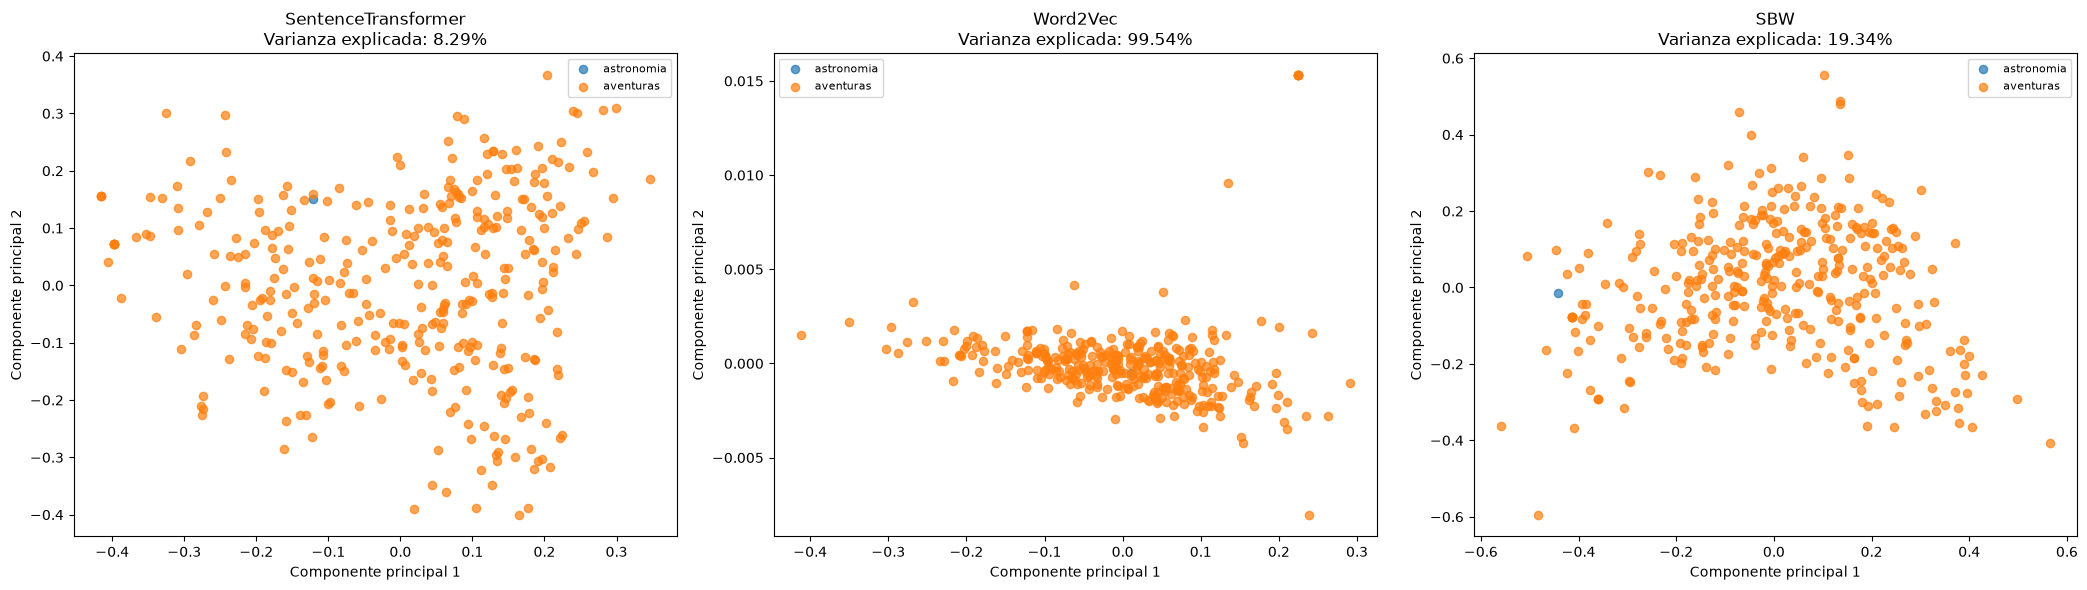

In [40]:
# Carga de los libros y conversión de columnas listas
libros_comparacion = pd.read_csv(RUTA_CSV_LIMPIO)
libros_comparacion["autores"] = libros_comparacion["autores"].apply(ast.literal_eval)
libros_comparacion["generos"] = libros_comparacion["generos"].apply(ast.literal_eval)

# Carga de los modelos ya generados
nombre_mejor_modelo, _ = parametros_word2vec(
    RUTA_MODELO / "mejor_modelo_parametros.txt"
)
modelo_w2v_comparacion = cargar_modelo(nombre_mejor_modelo)
modelo_sbw_comparacion = SBW_modelo(
    RUTA_MODELO / "SBW-vectors-300-min5.bin.gz"
)

# Representaciones de documentos
documentos = libros_comparacion["sinopsis"].fillna("").tolist()

modelo_sentence = SentenceTransformer("distiluse-base-multilingual-cased-v1")
documentos_crudos = (
    pd.read_csv(RUTA_CSV_ORIGINAL, keep_default_na=False)["sinopsis"].tolist()
)
vectores_sentence = modelo_sentence.encode(
    documentos_crudos,
    convert_to_numpy=True,
    show_progress_bar=False
)

def vector_documento(texto, modelo):
    palabras = str(texto).split()
    vectores = [
        modelo[word]
        for word in palabras
        if word in modelo.key_to_index
    ]

    if not vectores:
        return np.zeros(modelo.vector_size)

    return np.mean(vectores, axis=0)

vectores_w2v = np.vstack([
    vector_documento(texto, modelo_w2v_comparacion.wv)
    for texto in documentos
])

vectores_sbw = np.vstack([
    vector_documento(texto, modelo_sbw_comparacion)
    for texto in documentos
])

modelos_vectores = {
    "SentenceTransformer": vectores_sentence,
    "Word2Vec": vectores_w2v,
    "SBW": vectores_sbw,
}

def vector_consulta(consulta, modelo, limpiar=False):
    texto = limpiar_texto(consulta) if limpiar else consulta
    return vector_documento(texto, modelo)

def ranking_consulta(consulta, nombre_modelo, topn=5):
    if nombre_modelo == "SentenceTransformer":
        vector = modelo_sentence.encode([consulta], convert_to_numpy=True)
    elif nombre_modelo == "Word2Vec":
        vector = vector_consulta(
            consulta,
            modelo_w2v_comparacion.wv,
            limpiar=True
        ).reshape(1, -1)
    else:
        vector = vector_consulta(
            consulta,
            modelo_sbw_comparacion,
            limpiar=True
        ).reshape(1, -1)

    puntuaciones = cosine_similarity(
        vector,
        modelos_vectores[nombre_modelo]
    )[0]

    indices = np.argsort(puntuaciones)[::-1][:topn]

    return [
        (
            int(indice),
            libros_comparacion.iloc[indice]["titulo"],
            float(puntuaciones[indice])
        )
        for indice in indices
    ]

# Consultas en lenguaje natural
consultas = [
    "una novela de aventuras y viajes peligrosos",
    "una historia de amor entre dos personajes",
    "una investigación relacionada con un misterio"
]
def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(
        caracter
        for caracter in texto
        if not unicodedata.combining(caracter)
    )
    texto = re.sub(r"[^\w\s]", " ", texto)
    palabras = texto.split()
    palabras = [
        palabra for palabra in palabras
        if palabra not in STOPWORDS_ES
    ]
    return " ".join(palabras)
# Rankings lado a lado
for consulta in consultas:
    print(f"\nCONSULTA: {consulta}")

    rankings = {
        nombre: ranking_consulta(consulta, nombre, topn=5)
        for nombre in modelos_vectores
    }

    tabla = PrettyTable()
    tabla.field_names = [
        "Posición",
        "SentenceTransformer",
        "Word2Vec",
        "SBW"
    ]

    for posicion in range(5):
        fila = [posicion + 1]

        for nombre_modelo in modelos_vectores:
            _, titulo, puntuacion = rankings[nombre_modelo][posicion]
            fila.append(f"{titulo} ({puntuacion:.3f})")

        tabla.add_row(fila)

    print(tabla)

# Distribución de similitudes entre pares aleatorios
rng = np.random.default_rng(42)
cantidad_pares = min(5000, len(documentos) * (len(documentos) - 1) // 2)
pares_aleatorios = rng.integers(
    0,
    len(documentos),
    size=(cantidad_pares, 2)
)

for nombre_modelo, vectores in modelos_vectores.items():
    similitudes = []

    for i, j in pares_aleatorios:
        if i != j:
            similitud = cosine_similarity(
                vectores[i].reshape(1, -1),
                vectores[j].reshape(1, -1)
            )[0, 0]
            similitudes.append(similitud)

    similitudes = np.array(similitudes)

    print(f"\nDistribución de similitudes: {nombre_modelo}")
    print(f"Media: {similitudes.mean():.4f}")
    print(f"Desvío estándar: {similitudes.std():.4f}")
    print(f"Rango: [{similitudes.min():.4f}, {similitudes.max():.4f}]")

# Etiquetas de género
def genero_principal(generos):
    if not generos:
        return "Sin género"
    return generos[0]

generos = libros_comparacion["generos"].apply(genero_principal)

# Se conservan los géneros más frecuentes para facilitar la visualización
generos_frecuentes = generos.value_counts().head(8).index
generos_grafico = generos.where(
    generos.isin(generos_frecuentes),
    other="Otros"
)

# Proyección PCA
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (nombre_modelo, vectores) in zip(
    axes,
    modelos_vectores.items()
):
    pca = PCA(n_components=2, random_state=42)
    proyeccion = pca.fit_transform(vectores)

    varianza = pca.explained_variance_ratio_

    for genero in sorted(generos_grafico.unique()):
        mascara = generos_grafico == genero

        ax.scatter(
            proyeccion[mascara, 0],
            proyeccion[mascara, 1],
            label=genero,
            alpha=0.7,
            s=35
        )

    ax.set_title(
        f"{nombre_modelo}\n"
        f"Varianza explicada: "
        f"{varianza[0] + varianza[1]:.2%}"
    )
    ax.set_xlabel("Componente principal 1")
    ax.set_ylabel("Componente principal 2")
    ax.legend(fontsize=8)

    print(
        f"{nombre_modelo} - "
        f"PC1: {varianza[0]:.2%}, "
        f"PC2: {varianza[1]:.2%}, "
        f"total: {varianza.sum():.2%}"
    )

plt.tight_layout()
plt.show()